# Predicting Diabetes with Machine Learning

> **Portfolio project — binary classification on structured health data**

This project develops and evaluates machine-learning models for predicting diabetes from demographic, lifestyle, and clinical measurements. The emphasis is not only on predictive performance, but also on **appropriate evaluation for an imbalanced classification problem**, model interpretability, and the precision–recall trade-off.

**Key question:** Can we identify patients at elevated risk of diabetes while keeping false positives at a practical level?

**Important:** This is a machine-learning portfolio project, not a clinical diagnostic system. Any real-world deployment would require clinical validation, external validation, calibration, and appropriate governance.

## 1. Problem Definition

Diabetes is a chronic condition in which early identification can support timely clinical assessment and management. From a machine-learning perspective, this is a **binary classification problem**:

- `0` — no diabetes
- `1` — diabetes

The objective is to learn a mapping from patient-level features to the probability of diabetes.

### Why accuracy is not enough

The target is strongly imbalanced: only about **8.5%** of observations are positive. In this setting, a model can achieve high accuracy simply by favoring the majority class.

For a screening-oriented problem, **recall for the diabetic class** is especially important because a false negative means failing to flag a patient who has diabetes. Precision and F1-score are also monitored because increasing recall can create more false positives.

The project therefore evaluates:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Confusion matrix
- Threshold-dependent precision/recall trade-offs

## 2. Dataset

The project uses the **Diabetes Prediction Dataset** from Kaggle.

The dataset contains **100,000 patient records** and the following predictors:

| Feature | Description |
|---|---|
| `gender` | Patient gender |
| `age` | Patient age |
| `hypertension` | Whether hypertension is present |
| `heart_disease` | Whether heart disease is present |
| `smoking_history` | Smoking-history category |
| `bmi` | Body mass index |
| `HbA1c_level` | HbA1c measurement |
| `blood_glucose_level` | Blood glucose measurement |

### Target

`diabetes` is the binary target:

- `0` = No diabetes
- `1` = Diabetes

The dataset is therefore a supervised binary-classification problem.

## 3. Imports and Environment

The notebook uses pandas and NumPy for data handling, Matplotlib and Seaborn for visualization, and scikit-learn for preprocessing, model training, tuning, and evaluation.

The imports are intentionally kept in one place so the notebook has a clean, reproducible structure.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    cross_validate,
    StratifiedKFold
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    precision_recall_curve
)

RANDOM_STATE = 42

print(f"NumPy: {np.__version__}")
print(f"pandas: {pd.__version__}")
print(f"scikit-learn: {sklearn.__version__}")

NumPy: 2.5.1
pandas: 3.0.5
scikit-learn: 1.9.0


## 4. Loading the Data

In [2]:
df = pd.read_csv("data/diabetes_prediction_dataset.csv")

df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


### Initial observations

Before modeling, we first establish the dataset's shape, data types, missingness, duplicated rows, and target distribution. This prevents us from making assumptions about data quality before the modeling pipeline is defined.

In [3]:
print(f"Shape: {df.shape}")
display(df.info())

Shape: (100000, 9)
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  str    
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  str    
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 6.9 MB


None

In [4]:
df.isna().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [5]:
print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 3854


In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
gender,100000,3,Female,58552,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,100000.0,NaN,NaN,NaN,41.885856,22.51684,0.08,24.0,43.0,60.0,80.0
hypertension,100000.0,NaN,NaN,NaN,0.07485,0.26315,0.0,0.0,0.0,0.0,1.0
heart_disease,100000.0,NaN,NaN,NaN,0.03942,0.194593,0.0,0.0,0.0,0.0,1.0
smoking_history,100000,6,No Info,35816,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,100000.0,NaN,NaN,NaN,27.320767,6.636783,10.01,23.63,27.32,29.58,95.69
HbA1c_level,100000.0,NaN,NaN,NaN,5.527507,1.070672,3.5,4.8,5.8,6.2,9.0
blood_glucose_level,100000.0,NaN,NaN,NaN,138.05806,40.708136,80.0,100.0,140.0,159.0,300.0
diabetes,100000.0,NaN,NaN,NaN,0.085,0.278883,0.0,0.0,0.0,0.0,1.0


## 5. Exploratory Data Analysis

The EDA is designed to answer a specific question: **which variables appear to contain useful signal for separating diabetic and non-diabetic patients?**

EDA is exploratory rather than causal. A visible association does not mean that a feature causes diabetes, and it does not by itself establish clinical usefulness.

### 5.1 Target Distribution

In [7]:
target_counts = df["diabetes"].value_counts().sort_index()
target_rates = df["diabetes"].value_counts(normalize=True).sort_index()

display(pd.DataFrame({
    "count": target_counts,
    "proportion": target_rates
}))

,count,proportion
diabetes,,
0,91500,0.915
1,8500,0.085


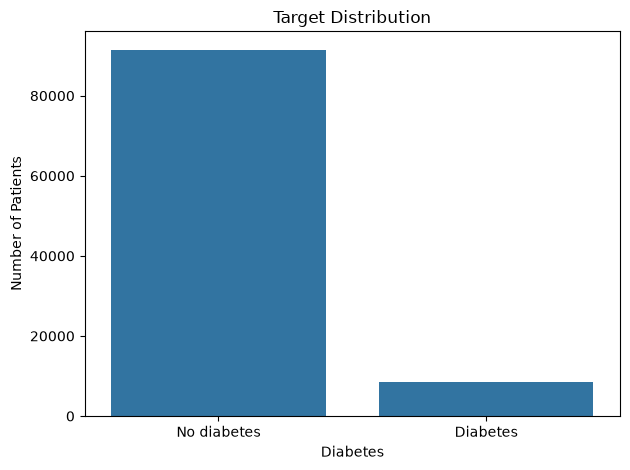

In [8]:
ax = sns.countplot(data=df, x="diabetes")

ax.set_title("Target Distribution")
ax.set_xlabel("Diabetes")
ax.set_ylabel("Number of Patients")

ax.set_xticks([0, 1])
ax.set_xticklabels(["No diabetes", "Diabetes"])

plt.tight_layout()
plt.show()

### Interpretation

The positive class represents approximately **8.5%** of the dataset, while the remaining **91.5%** are non-diabetic. This imbalance makes raw accuracy an insufficient primary metric.

For example, a naive classifier that predicted `0` for every patient would already achieve about **91.5% accuracy** while detecting none of the diabetic cases. The modeling strategy therefore prioritizes class-specific precision, recall, F1-score, and ROC-AUC.

### 5.2 Categorical Features

In [9]:
categorical_features = ["gender", "hypertension", "heart_disease", "smoking_history"]

for feature in categorical_features:
    print(f"\n--- {feature} ---")
    rates = df.groupby(feature)["diabetes"].agg(["mean", "count"])
    rates["diabetes_rate_%"] = rates["mean"] * 100
    display(rates.sort_values("diabetes_rate_%", ascending=False))


--- gender ---


,mean,count,diabetes_rate_%
gender,,,
Male,0.097490,41430,9.748974
Female,0.076189,58552,7.618869
Other,0.000000,18,0.000000



--- hypertension ---


,mean,count,diabetes_rate_%
hypertension,,,
1,0.278958,7485,27.895792
0,0.069308,92515,6.930768



--- heart_disease ---


,mean,count,diabetes_rate_%
heart_disease,,,
1,0.321410,3942,32.141045
0,0.075298,96058,7.529826



--- smoking_history ---


,mean,count,diabetes_rate_%
smoking_history,,,
former,0.170017,9352,17.001711
ever,0.117882,4004,11.788212
not current,0.107027,6447,10.702652
current,0.102089,9286,10.208917
never,0.095341,35095,9.534122
No Info,0.040596,35816,4.059638


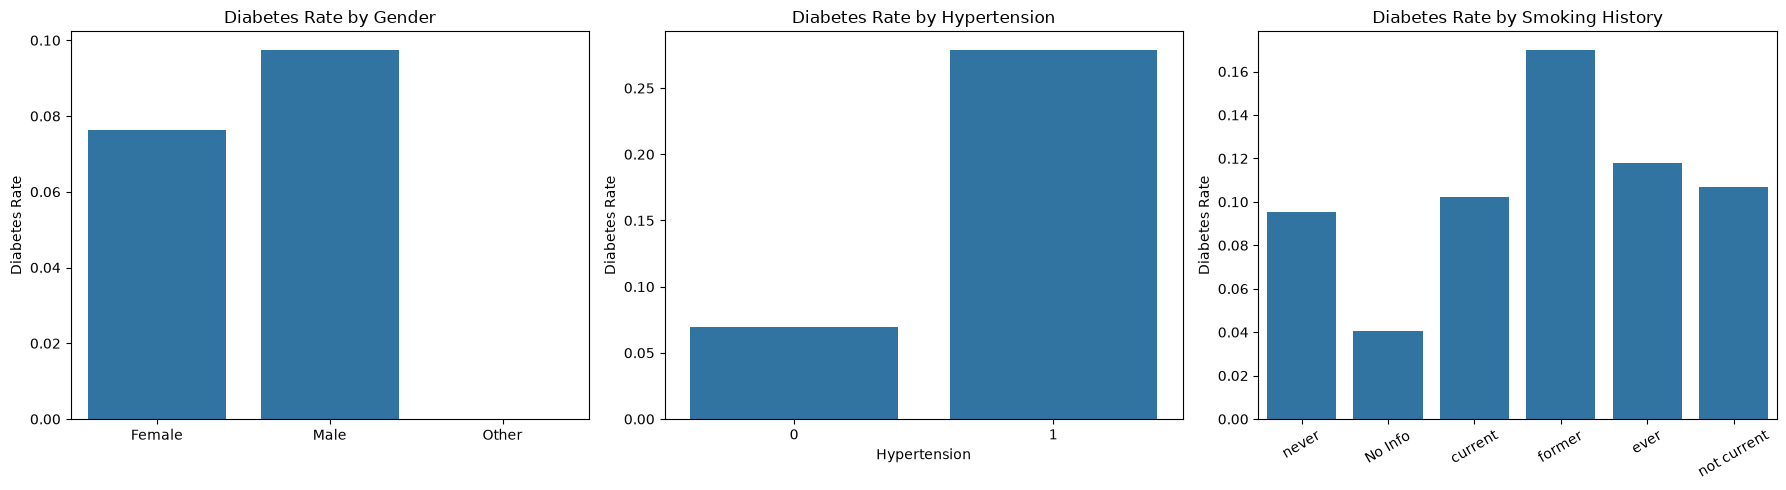

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(
    data=df,
    x="gender",
    y="diabetes",
    estimator="mean",
    errorbar=None,
    ax=axes[0]
)
axes[0].set_title("Diabetes Rate by Gender")
axes[0].set_ylabel("Diabetes Rate")
axes[0].set_xlabel("")

sns.barplot(
    data=df,
    x="hypertension",
    y="diabetes",
    estimator="mean",
    errorbar=None,
    ax=axes[1]
)
axes[1].set_title("Diabetes Rate by Hypertension")
axes[1].set_ylabel("Diabetes Rate")
axes[1].set_xlabel("Hypertension")

sns.barplot(
    data=df,
    x="smoking_history",
    y="diabetes",
    estimator="mean",
    errorbar=None,
    ax=axes[2]
)
axes[2].set_title("Diabetes Rate by Smoking History")
axes[2].set_ylabel("Diabetes Rate")
axes[2].set_xlabel("")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

### Interpretation

The categorical variables do not contribute equally.

- **Hypertension** shows a clear difference in diabetes prevalence between groups.
- **Smoking history** also shows differences across categories, although the interpretation is complicated by the `No Info` category and by the observational nature of the dataset.
- **Gender** shows a comparatively smaller difference in diabetes prevalence.

These are associations in this dataset, not causal effects. Their ultimate value will be determined by out-of-sample model performance rather than by EDA alone.

### 5.3 Numerical Features

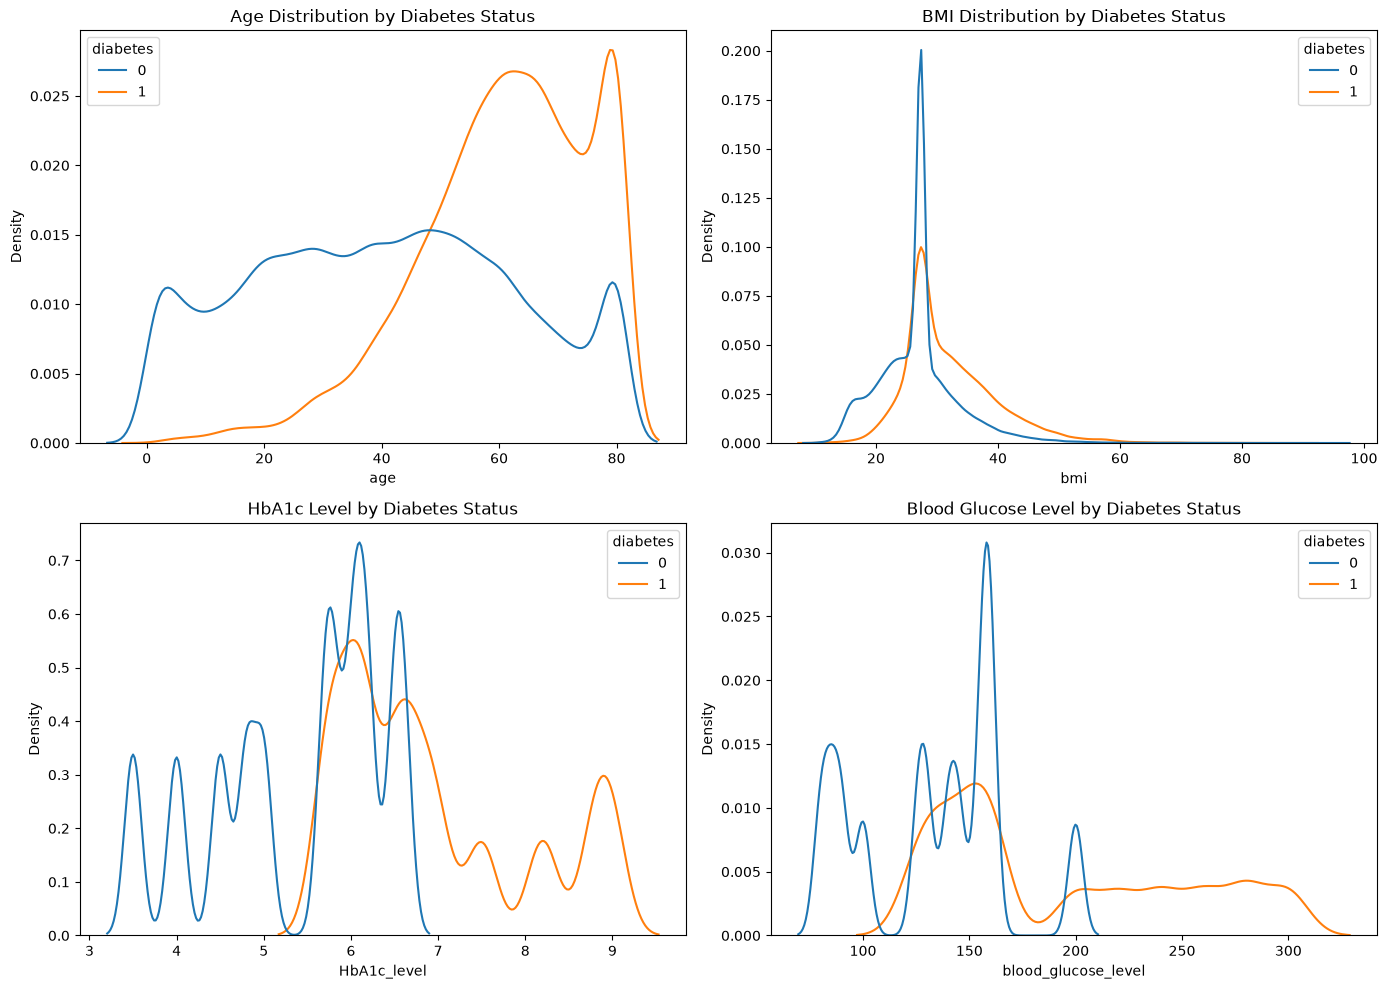

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.kdeplot(data=df, x="age", hue="diabetes", common_norm=False, ax=axes[0, 0])
axes[0, 0].set_title("Age Distribution by Diabetes Status")

sns.kdeplot(data=df, x="bmi", hue="diabetes", common_norm=False, ax=axes[0, 1])
axes[0, 1].set_title("BMI Distribution by Diabetes Status")

sns.kdeplot(data=df, x="HbA1c_level", hue="diabetes", common_norm=False, ax=axes[1, 0])
axes[1, 0].set_title("HbA1c Level by Diabetes Status")

sns.kdeplot(data=df, x="blood_glucose_level", hue="diabetes", common_norm=False, ax=axes[1, 1])
axes[1, 1].set_title("Blood Glucose Level by Diabetes Status")

plt.tight_layout()
plt.show()

### Interpretation

The numerical distributions suggest that:

- **Age** provides meaningful separation, with diabetes concentrated more heavily among older patients.
- **BMI** shows overlap between the classes, indicating useful but non-deterministic signal.
- **HbA1c** and **blood glucose** show the strongest visual separation.

This pattern is important because it gives us a hypothesis to test later: if these two clinical measurements dominate feature importance, the model may be relying primarily on direct metabolic indicators rather than demographic variables.

### 5.4 Correlation Analysis

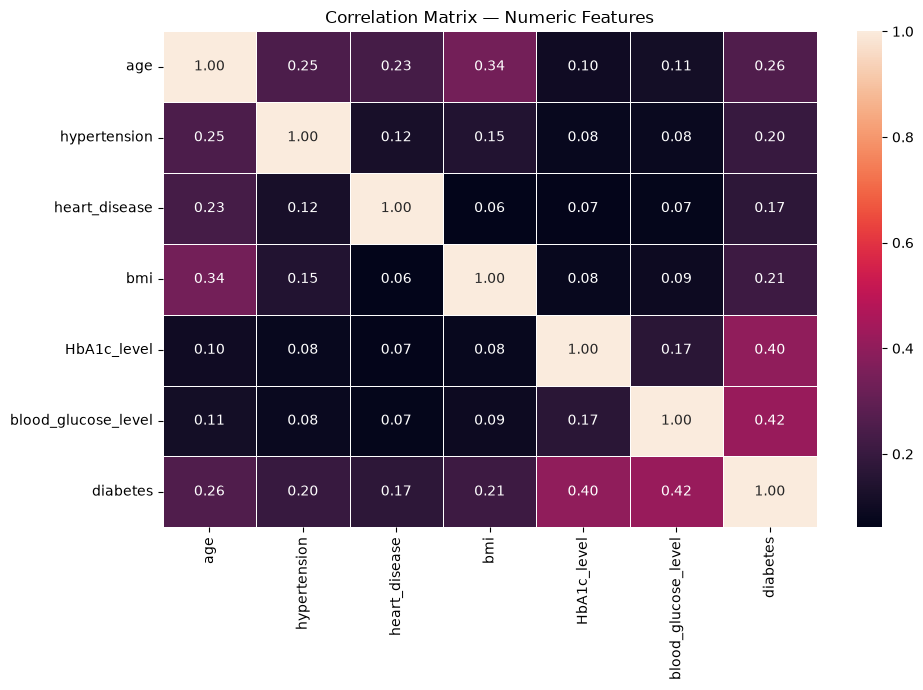

In [12]:
numeric_corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(10, 7))
sns.heatmap(numeric_corr, annot=True, fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix — Numeric Features")
plt.tight_layout()
plt.show()

### Interpretation

Correlation is useful as an exploratory diagnostic, but it is **not a substitute for model-based feature evaluation**. Correlation only captures linear association and can miss nonlinear relationships.

The strongest relationships with the target are expected to come from `HbA1c_level` and `blood_glucose_level`, which is consistent with the distribution plots above. We will verify their contribution after the final model is trained.

## 6. Modeling Strategy

A key methodological requirement is to prevent **data leakage**.

The preprocessing objects are therefore fitted **only on the training data** through scikit-learn `Pipeline` and `ColumnTransformer`. The test set remains untouched until final evaluation.

Categorical variables are one-hot encoded rather than ordinal encoded. This avoids introducing an artificial numeric ordering into nominal categories such as gender or smoking history.

For algorithms that are sensitive to feature scale, numerical variables are standardized. Tree-based models do not require scaling, but using separate pipelines keeps preprocessing explicit and reproducible.

In [13]:
X = df.drop(columns="diabetes")
y = df["diabetes"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)
print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))
print("\nTest target distribution:")
print(y_test.value_counts(normalize=True))

Training set: (80000, 8)
Test set: (20000, 8)

Training target distribution:
diabetes
0    0.915
1    0.085
Name: proportion, dtype: float64

Test target distribution:
diabetes
0    0.915
1    0.085
Name: proportion, dtype: float64


In [14]:
categorical_features = ["gender", "smoking_history"]
binary_features = ["hypertension", "heart_disease"]
numeric_features = ["age", "bmi", "HbA1c_level", "blood_glucose_level"]

scaled_preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
        ("numeric", StandardScaler(), numeric_features),
        ("binary", "passthrough", binary_features),
    ],
    verbose_feature_names_out=False
)

tree_preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
        ("numeric", "passthrough", numeric_features),
        ("binary", "passthrough", binary_features),
    ],
    verbose_feature_names_out=False
)

## 7. Baseline Model Comparison

We compare several standard classifiers before spending compute on hyperparameter tuning:

- Logistic Regression — strong, interpretable linear baseline
- K-Nearest Neighbors — local, distance-based baseline
- Random Forest — nonlinear ensemble model
- Linear SVM — another linear decision boundary
- Gaussian Naive Bayes — probabilistic baseline

The goal is not to find the most sophisticated algorithm immediately. It is to establish a meaningful baseline and understand whether additional model complexity is justified.

In [15]:
models = {
    "Logistic Regression": Pipeline([
        ("preprocessor", scaled_preprocessor),
        ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
    ]),
    "KNN": Pipeline([
        ("preprocessor", scaled_preprocessor),
        ("model", KNeighborsClassifier())
    ]),
    "Random Forest": Pipeline([
        ("preprocessor", tree_preprocessor),
        ("model", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
    ]),
    "Linear SVM": Pipeline([
        ("preprocessor", scaled_preprocessor),
        ("model", LinearSVC(max_iter=10000, random_state=RANDOM_STATE))
    ]),
    "Naive Bayes": Pipeline([
        ("preprocessor", scaled_preprocessor),
        ("model", GaussianNB())
    ])
}

baseline_rows = []

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    baseline_rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0)
    })

baseline_results = pd.DataFrame(baseline_rows).sort_values("F1", ascending=False)
baseline_results

,Model,Accuracy,Precision,Recall,F1
2,Random Forest,0.97030,0.943109,0.692353,0.798507
0,Logistic Regression,0.96045,0.859289,0.639412,0.733221
1,KNN,0.96055,0.884388,0.616471,0.726516
3,Linear SVM,0.96035,0.883997,0.614118,0.724748
4,Naive Bayes,0.64020,0.187016,0.965882,0.313359


### Interpretation

Because the dataset is imbalanced, the baseline comparison is read primarily through **diabetic-class recall, precision, and F1**, rather than accuracy alone.

If Random Forest provides the strongest minority-class trade-off while retaining competitive accuracy, it is a reasonable candidate for further tuning. The final choice should be justified by the project's error costs, not simply by the highest accuracy.

## 8. Random Forest Hyperparameter Tuning

Random Forest is tuned using cross-validation on the **training set only**.

The search is evaluated with **ROC-AUC** as the primary optimization metric. This keeps threshold selection separate from model fitting: the model learns to rank observations, and the operating threshold can then be chosen according to the desired precision–recall trade-off.

This separation is important. Choosing a threshold directly on the final test set would leak information from the evaluation set into the model-selection process.

In [16]:
rf_pipeline = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("model", RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf_param_grid = {
    "model__n_estimators": [150, 300, 450],
    "model__max_depth": [10, 15, 25, None],
    "model__min_samples_split": [2, 5, 10, 15],
    "model__min_samples_leaf": [1, 3, 5, 7],
    "model__max_features": ["sqrt", "log2"]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_grid,
    n_iter=20,
    scoring="roc_auc",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train, y_train)

print("Best parameters:")
print(rf_search.best_params_)
print(f"Best CV ROC-AUC: {rf_search.best_score_:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters:
{'model__n_estimators': 450, 'model__min_samples_split': 2, 'model__min_samples_leaf': 3, 'model__max_features': 'sqrt', 'model__max_depth': 15}
Best CV ROC-AUC: 0.9733


### Why cross-validation belongs inside the training set

The test set is the final simulation of unseen data. If it is repeatedly inspected while selecting hyperparameters or thresholds, it gradually stops being an unbiased evaluation set.

The workflow used here is therefore:

**Training data → cross-validation → model selection → validation/operating-threshold selection → one final test evaluation.**

For a production-grade study, the threshold can be selected using a dedicated validation set or out-of-fold predictions from the training data.

## 9. Final Model Evaluation

First evaluate the tuned model at the default probability threshold of 0.50. This establishes the baseline behavior of the selected model before any threshold adjustment.

In [17]:
best_rf = rf_search.best_estimator_

test_proba = best_rf.predict_proba(X_test)[:, 1]
test_pred_050 = (test_proba >= 0.50).astype(int)

print(classification_report(
    y_test,
    test_pred_050,
    target_names=["No diabetes", "Diabetes"],
    digits=3
))

print(f"ROC-AUC: {roc_auc_score(y_test, test_proba):.4f}")

              precision    recall  f1-score   support

 No diabetes      0.971     0.999     0.985     18300
    Diabetes      0.990     0.681     0.807      1700

    accuracy                          0.972     20000
   macro avg      0.980     0.840     0.896     20000
weighted avg      0.973     0.972     0.970     20000

ROC-AUC: 0.9736


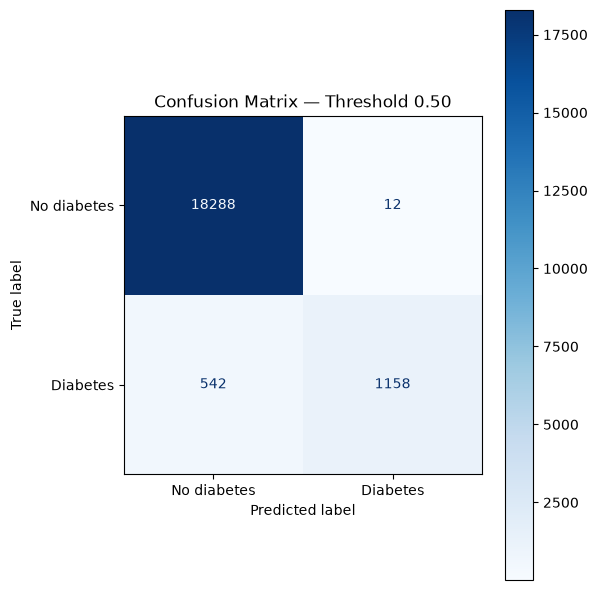

In [18]:
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_pred_050,
    display_labels=["No diabetes", "Diabetes"],
    cmap="Blues",
    ax=ax
)
ax.set_title("Confusion Matrix — Threshold 0.50")
plt.tight_layout()
plt.show()

### Interpretation

The confusion matrix makes the central modeling trade-off explicit:

- **False negatives** are diabetic patients that the model fails to flag.
- **False positives** are non-diabetic patients that are incorrectly flagged.

Because missing a diabetic patient can be more consequential in a screening scenario, it is reasonable to investigate whether a lower threshold improves recall enough to justify the additional false positives.

### 9.1 ROC Curve

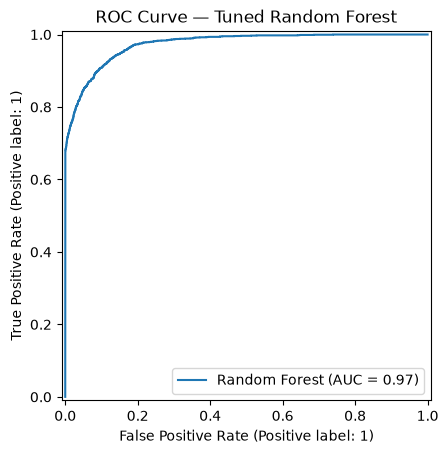

In [19]:
RocCurveDisplay.from_predictions(
    y_test,
    test_proba,
    name="Random Forest"
)
plt.title("ROC Curve — Tuned Random Forest")
plt.show()

### Interpretation

The ROC curve summarizes the model's ability to rank positive cases above negative cases across a range of thresholds. A high ROC-AUC indicates strong class-separation ability, but it does **not** tell us which threshold is appropriate for a real decision.

That is why threshold analysis is performed separately.

## 10. Decision-Threshold Analysis

A probabilistic classifier does not inherently say "diabetes" or "no diabetes"; it produces a probability. The threshold converts that probability into a class label.

Lowering the threshold generally increases recall while reducing precision. The correct operating point depends on the cost of false negatives versus false positives.

The threshold analysis below is therefore treated as a **decision-policy analysis**, not as additional model training.

In [20]:
thresholds = np.arange(0.20, 0.61, 0.05)

threshold_rows = []

for threshold in thresholds:
    pred = (test_proba >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()

    threshold_rows.append({
        "Threshold": round(threshold, 2),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "False Positives": fp,
        "False Negatives": fn
    })

threshold_results = pd.DataFrame(threshold_rows)
threshold_results

,Threshold,Precision,Recall,F1,False Positives,False Negatives
0,0.20,0.748173,0.782941,0.765162,448,369
1,0.25,0.838070,0.745882,0.789293,245,432
2,0.30,0.909159,0.718235,0.802498,122,479
3,0.35,0.945989,0.700588,0.805002,68,509
4,0.40,0.965318,0.687647,0.803160,42,531
5,0.45,0.982264,0.684118,0.806519,21,537
6,0.50,0.989744,0.681176,0.806969,12,542
7,0.55,0.995678,0.677647,0.806440,5,548
8,0.60,1.000000,0.674706,0.805760,0,553


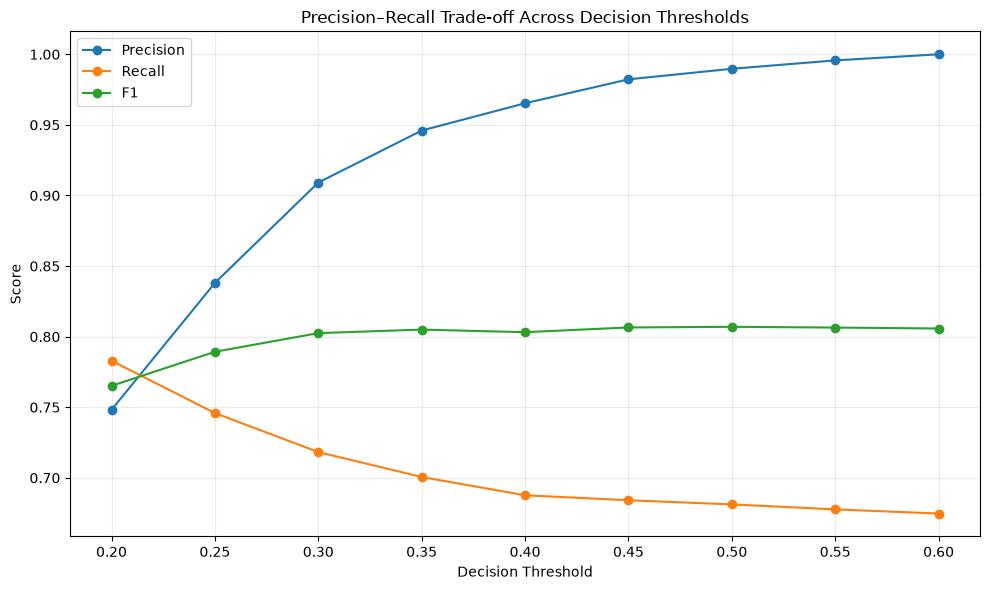

In [21]:
plt.figure(figsize=(10, 6))
plt.plot(threshold_results["Threshold"], threshold_results["Precision"], marker="o", label="Precision")
plt.plot(threshold_results["Threshold"], threshold_results["Recall"], marker="o", label="Recall")
plt.plot(threshold_results["Threshold"], threshold_results["F1"], marker="o", label="F1")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Precision–Recall Trade-off Across Decision Thresholds")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### Threshold selection

For a portfolio project, the threshold should not be chosen because it happens to produce the prettiest test-set metric.

A stronger approach is to define the business/clinical objective first. For example:

> **Select the highest-recall threshold subject to precision remaining above a predefined minimum.**

The following example uses a configurable precision constraint. The exact constraint should be justified by the intended use case rather than treated as a universal clinical rule.

In [22]:
MIN_PRECISION = 0.90

eligible = threshold_results[
    threshold_results["Precision"] >= MIN_PRECISION
].sort_values(["Recall", "F1"], ascending=False)

eligible.head()

,Threshold,Precision,Recall,F1,False Positives,False Negatives
2,0.30,0.909159,0.718235,0.802498,122,479
3,0.35,0.945989,0.700588,0.805002,68,509
4,0.40,0.965318,0.687647,0.803160,42,531
5,0.45,0.982264,0.684118,0.806519,21,537
6,0.50,0.989744,0.681176,0.806969,12,542


## 11. Cross-Validated Performance

A single train/test split can be informative, but it can also be affected by the particular observations that land in the test set.

We therefore use stratified 5-fold cross-validation on the training data to estimate the stability of the selected model. The final test set remains untouched by this process.

In [23]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_results = cross_validate(
    best_rf,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

cv_summary = pd.DataFrame({
    metric: cv_results[f"test_{metric}"]
    for metric in scoring
})

cv_summary.loc["mean"] = cv_summary.mean()
cv_summary.loc["std"] = cv_summary.std()

cv_summary

,accuracy,precision,recall,f1,roc_auc
0,0.970625,0.993348,0.658824,0.792219,0.971051
1,0.971938,0.991370,0.675735,0.803673,0.972097
2,0.973500,0.994715,0.691912,0.816132,0.974593
3,0.971000,0.992308,0.663971,0.795595,0.975013
4,0.972000,0.996732,0.672794,0.803336,0.973645
mean,0.971813,0.993694,0.672647,0.802191,0.973280
std,0.000997,0.001882,0.011376,0.008256,0.001499


### Interpretation

The cross-validation mean and standard deviation provide a more informative picture than a single score. Small fold-to-fold variation suggests stable performance, while large variation would indicate sensitivity to the training sample.

The most important question remains whether recall is high enough for the intended application. A model can be highly accurate and still systematically miss a substantial fraction of positive cases.

## 12. Feature Importance

Random Forest provides impurity-based feature importance, which measures how much each feature contributes to reducing impurity across the trees.

Because the categorical variables are one-hot encoded, the importance values are reported at the **transformed-feature level**. This is more appropriate than assigning an arbitrary ordinal number to nominal categories.

Feature importance should be interpreted as model behavior, not as causal evidence.

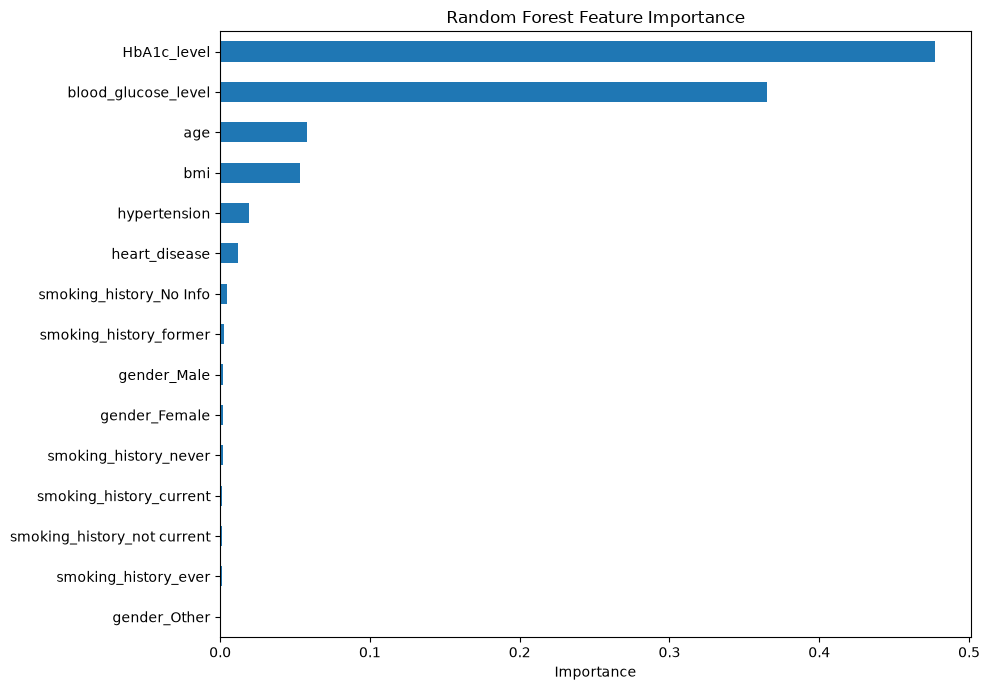

In [24]:
rf_model = best_rf.named_steps["model"]
feature_names = best_rf.named_steps["preprocessor"].get_feature_names_out()

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=feature_names
).sort_values(ascending=True)

plt.figure(figsize=(10, 7))
feature_importance.plot(kind="barh")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

### Interpretation

The feature-importance ranking should be compared with the EDA rather than interpreted in isolation.

If `HbA1c_level` and `blood_glucose_level` dominate the ranking, the result is consistent with the strong separation observed in the distributions and supports the conclusion that the model relies heavily on direct clinical measurements.

A useful follow-up experiment is to compare the full model against a deliberately simplified model using only the strongest features. If performance remains similar, the simpler model may be preferable because it is easier to explain and maintain.

## 13. Final Model Summary

At this point the analysis should answer four questions clearly:

1. **Does the model perform better than simple baselines?**
2. **How well does it detect the diabetic class?**
3. **How does changing the threshold affect the error trade-off?**
4. **Which variables drive the model's predictions?**

The final reported metrics should come from the **untouched test set**, while all preprocessing and model-selection decisions are made using training data and cross-validation.

### Practical conclusion

The strongest model is useful as a predictive demonstration, but it should not be described as a medical diagnostic tool. Its limitations include class imbalance, dependence on the source dataset, possible population shift, and the need for external validation.

For a real clinical application, the next steps would include:

- external validation on an independent population;
- probability calibration;
- explicit false-negative/false-positive cost analysis;
- subgroup performance analysis;
- threshold selection using a clinically justified operating point;
- prospective validation and clinical oversight.

## 14. Key Takeaways

- The dataset is strongly imbalanced, so **accuracy alone is misleading**.
- Random Forest provides a strong nonlinear baseline for the tabular data.
- **Recall for the diabetic class is the critical weakness to monitor**, because false negatives matter in a screening context.
- Threshold tuning provides direct control over the precision–recall trade-off.
- `HbA1c_level` and `blood_glucose_level` are expected to be the dominant predictive variables.
- The corrected pipeline prevents preprocessing leakage by fitting transformations only on training folds.
- The model's predictions should be interpreted as statistical estimates, **not medical diagnoses**.